# Exploratory Data Analysis (EDA)

this dataset is unstructure data (text)

curiousity : ทำไม comment หลายอัน ถึงไม่ได้จัดอยู่ใน class ไหนเลย ( 0 หมด )

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer
import re
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams['font.family'] = 'Tahoma'

## Load data

In [4]:
df = pd.read_csv('../data/train.csv')

In [5]:
df.columns

Index(['id', 'comment', 'สำนักงานตำรวจแห่งชาติ',
       'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย', 'สภาเด็กและเยาวชนกรุงเทพมหานคร',
       'กรมควบคุมมลพิษ', 'กรมสรรพสามิต', 'การไฟฟ้านครหลวง', 'กรมทางหลวง',
       'สำนักงานประกันสุขภาพแห่งชาติ', 'การประปานครหลวง',
       'คณะกรรมการการพัฒนาเศรษฐกิจ', 'กระทรวงการท่องเที่ยวและกีฬา',
       'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200'],
      dtype='object')

In [6]:
df.shape

(306419, 14)

In [7]:
df.info

<bound method DataFrame.info of             id                                            comment  \
0            0                 ทำไมปล่อยให้จุดพลุกันสนั่นหวั่นไหว   
1            1  แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...   
2            2  คาดว่ามีการจุดพลุไม่ขอทางกรุงเทพให้ถูกต้อง ส่ง...   
3            3  ไม่แน่ใจ กทม อนุญาตให้ร้านชอคโกแลตวิลจุพลุถึงก...   
4            4  ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...   
...        ...                                                ...   
306414  306414                                     ขับรถบนทางเท้า   
306415  306415  ฝาท่อน้ำเหล็ก ข้างร้านเดอะโลคอล ซ.สุชุมวิท 23 ...   
306416  306416  กรุณาตรวจสอบการดำเนินการก่อสร้างฟุตบาทถนนพุทธบ...   
306417  306417  ถนนศรีอยุธยาชำรุด บริเวณหน้าทางเข้าตึกวรรณสรณ์...   
306418  306418  งานก่อปรับปรุงก่อสร้างซอยพระรามที่2\nซอย62 ในซ...   

        สำนักงานตำรวจแห่งชาติ  การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย  \
0                           0                                  0   
1  

In [8]:
df.describe(include="all")
# มี missing value -> ต้อง clean

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
count,306419.000000,304284,306419.000000,306419.000000,306419.000000,306419.000000,306419.000000,306419.000000,306419.000000,306419.000000,306419.000000,306419.000000,306419.000000,306419.000000
unique,NaN,274585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,จอดรถบนทางเท้า,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,153209.000000,NaN,0.114869,0.008550,0.000108,0.006449,0.000160,0.065463,0.025122,0.000255,0.009921,0.000098,0.000137,0.014989
std,88455.690405,NaN,0.318864,0.092072,0.010377,0.080044,0.012645,0.247341,0.156497,0.015953,0.099109,0.009894,0.011707,0.121510
min,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,76604.500000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,153209.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,229813.500000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [9]:
df.isnull().sum()

id                                          0
comment                                  2135
สำนักงานตำรวจแห่งชาติ                       0
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย           0
สภาเด็กและเยาวชนกรุงเทพมหานคร               0
กรมควบคุมมลพิษ                              0
กรมสรรพสามิต                                0
การไฟฟ้านครหลวง                             0
กรมทางหลวง                                  0
สำนักงานประกันสุขภาพแห่งชาติ                0
การประปานครหลวง                             0
คณะกรรมการการพัฒนาเศรษฐกิจ                  0
กระทรวงการท่องเที่ยวและกีฬา                 0
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200       0
dtype: int64

## Target Analysis

Class distribution

In [10]:
target_columns = ['สำนักงานตำรวจแห่งชาติ',
       'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย', 'สภาเด็กและเยาวชนกรุงเทพมหานคร',
       'กรมควบคุมมลพิษ', 'กรมสรรพสามิต', 'การไฟฟ้านครหลวง', 'กรมทางหลวง',
       'สำนักงานประกันสุขภาพแห่งชาติ', 'การประปานครหลวง',
       'คณะกรรมการการพัฒนาเศรษฐกิจ', 'กระทรวงการท่องเที่ยวและกีฬา',
       'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200']

class_cnt = df[target_columns].sum()
class_cnt.sort_values(ascending=False)
class_cnt

สำนักงานตำรวจแห่งชาติ                    35198
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย         2620
สภาเด็กและเยาวชนกรุงเทพมหานคร               33
กรมควบคุมมลพิษ                            1976
กรมสรรพสามิต                                49
การไฟฟ้านครหลวง                          20059
กรมทางหลวง                                7698
สำนักงานประกันสุขภาพแห่งชาติ                78
การประปานครหลวง                           3040
คณะกรรมการการพัฒนาเศรษฐกิจ                  30
กระทรวงการท่องเที่ยวและกีฬา                 42
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200     4593
dtype: int64

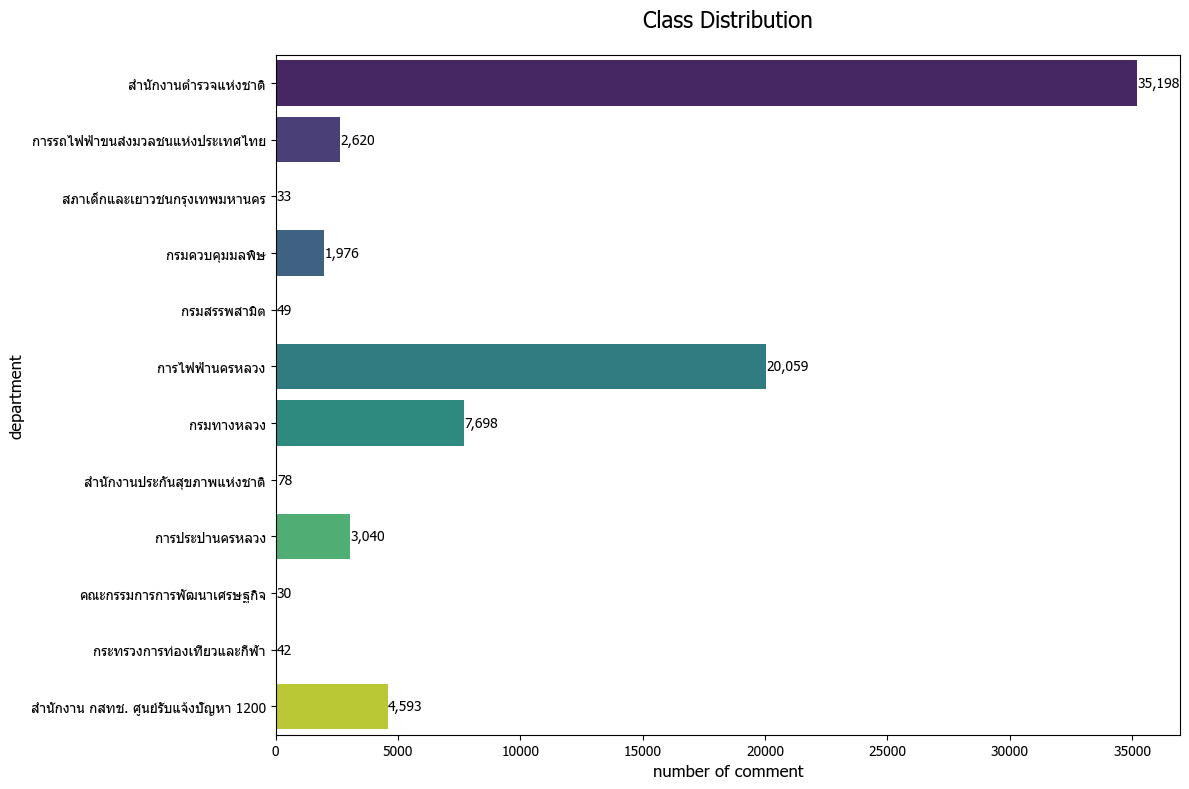

In [11]:
plt.figure(figsize=(12, 8))

ax = sns.barplot(x=class_cnt.values, y=class_cnt.index, palette='viridis')

for i, v in enumerate(class_cnt.values):
    ax.text(x=v + 10, y=i, s=f"{int(v):,}", va='center', fontsize=10)

plt.title('Class Distribution', fontsize=16, pad=20)
plt.xlabel('number of comment', fontsize=12)
plt.ylabel('department', fontsize=12)

plt.tight_layout()
plt.show()

In [52]:
counts = df[target_columns].sum()
counts.median()

2298.0

In [12]:
# นับจำนวน comment ที่ label เป็น 0 หมด
all_zero_cnt = (df[target_columns].sum(axis=1) == 0).sum()
all_zero_cnt

233241

In [13]:
# มี 233241 data จาก 306419 ที่ label เป็น 0 หมด -> 76%
# target imbalance

Correlation heatmap between classes (ดูว่ามี 2 หน่วยงานที่ถูก label พร้อมกันบ่อยๆหรือไม่)

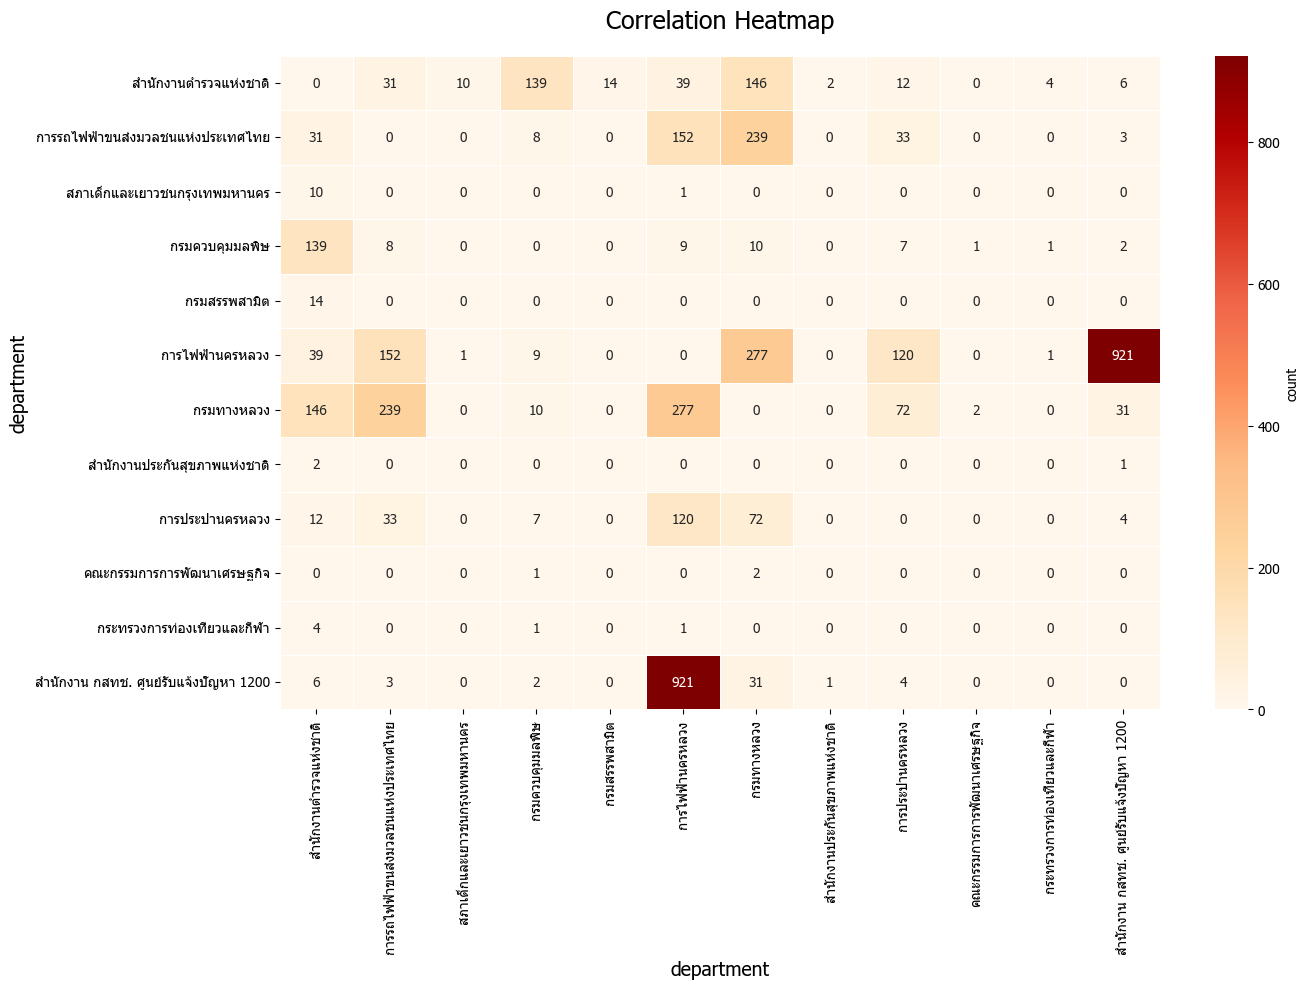

In [14]:
co_oc_matrix = df[target_columns].T.dot(df[target_columns]) # X^T * X เพื่อหาจุดตัด
np.fill_diagonal(co_oc_matrix.values, 0) # เส้นทแยงมุม คือตัวมันเองคูณตัวมันเอง -> set ให้เปน 0 

plt.figure(figsize=(14, 10))

sns.heatmap(co_oc_matrix, 
            annot=True,       
            fmt='d',          
            cmap='OrRd',      
            linewidths=0.5,   
            cbar_kws={'label': 'count'})

plt.title('Correlation Heatmap', fontsize=18, pad=20)
plt.xlabel('department', fontsize=14)
plt.ylabel('department', fontsize=14)

plt.tight_layout()
plt.show()

In [15]:
# insight : 
# 921 : การไฟฟ้า กับ กสทช.
# 277 : หรมทางหลวง กับ การไฟฟ้า
# 239 : กรมทางหลวง กับ กรมรถไฟฟ้าและขนส่ง

In [16]:
con_1 = (df['การไฟฟ้านครหลวง'] == 1) & (df['สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200'] == 1)
con_2 = (df['การไฟฟ้านครหลวง'] == 1) & (df['กรมทางหลวง'] == 1)
con_3 = (df['การไฟฟ้านครหลวง'] == 1) & (df['การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย'] == 1)

In [17]:
df[con_1].head(5) # ส่วนใหญ่จะเป็นเรื่องสายไฟห้อย (สารสื่อสารด้วย)

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
498,498,สายไฟห้อยลงมาหลายตำแหน่ง เหมือนสายไฟขาดจากการโ...,0,0,0,0,0,1,0,0,0,0,0,1
515,515,ปัญหา: พบบาทวิถีชำรุดแตกร้าว กว้างประมาณ 1 เมต...,0,0,0,0,0,1,0,0,0,0,0,1
679,679,สายสื่อสารร่วงลงมาบนถนน,0,0,0,0,0,1,0,0,0,0,0,1
1128,1128,มีสายไฟระวางบนพื้นถนนค่ะ,0,0,0,0,0,1,0,0,0,0,0,1
1374,1374,ขอบริมนำ้แตก,0,0,0,0,0,1,0,0,0,0,0,1


In [18]:
df[con_2].head(5) # พวกไฟถนนเสีย

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
85,85,ไฟถนนดับ จุดวนขึ้น\nจากเพชรเกษม มุ่งหน้าสาทร\n...,0,0,0,0,0,1,1,0,0,0,0,0
936,936,NaN,0,0,0,0,0,1,1,0,0,0,0,0
938,938,NaN,0,0,0,0,0,1,1,0,0,0,0,0
2336,2336,ไฟเสีย,1,0,0,0,0,1,1,0,0,0,0,0
2514,2514,ไฟฟ้าที่ป้ายรถเมล์หน้า Central รามอินทรา ดับเร...,0,0,0,0,0,1,1,0,0,0,0,0


In [19]:
df[con_3].head(10)

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
137,137,ถนนไม่ดีเวลาขับผ่านรถสะเทือนอย่างมาก,0,1,0,0,0,1,0,0,0,0,0,0
902,902,หลอดไฟใต้สถานีวงศ์สว่าง ดับเกือบหมดแล้ว ไม่แก้...,0,1,0,0,0,1,0,0,0,0,0,0
1123,1123,ถนนเป็นหลุมเป็นบ่อเกิดจากการทำรถไฟฟ้าติดฝาท่อโ...,0,1,0,0,0,1,0,0,0,0,0,0
2329,2329,ป้ายรถเมล์บริเวณหน้า MRT ตรงข้ามศูนย์ประชุมแห่...,0,1,0,0,0,1,0,0,0,0,0,0
2407,2407,มีสายไฟ ที่ไม่ต่อลงดิน มีกระแสไฟ อยู่ตรงทางขึ้...,0,1,0,0,0,1,0,0,0,0,0,0
2648,2648,ศูนย์เรื่องราวร้องทุกข์ ได้รับการประสานผ่านระบ...,0,1,0,0,0,1,0,0,0,0,0,0
2804,2804,เสาไฟฟ้ากำลังจะล้ม มีเสาค้ำยันไม่ทราบหน่วยงานไ...,0,1,0,0,0,1,0,0,0,0,0,1
4202,4202,ฟุตบาทล้ม อันตรายจากการก่อสร้างท่อร้อยสายไฟ ไม...,0,1,0,0,0,1,0,0,0,0,0,0
5880,5880,พื้นถนนขรุขระ ไม่เรียบ รถวิ่งกระแทกหลายคัน พื้...,0,1,0,0,0,1,0,0,0,0,0,0
6090,6090,ปัญหา: ประชาชนต้องการให้เร่งคืนพื้นที่ผิวจราจร...,0,1,0,0,0,1,0,0,0,0,0,0


## Feature Analysis

text length

In [20]:
df['text_length'] = df['comment'].astype(str).apply(len)

In [21]:
df['text_length'].min()

1

In [22]:
df['text_length'].max()

9999

In [ ]:
df[df['text_length']==9999]

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200,text_length
287235,287235,เรียนท่านผู้ว่าราชการกรุงเทพมหานคร อธิบดีกรมเจ...,0,0,0,0,0,0,0,0,0,0,0,0,9999


In [61]:
print(df[df['text_length']==9999]['comment'].values[0])

เรียนท่านผู้ว่าราชการกรุงเทพมหานคร อธิบดีกรมเจ้าท่า และผู้อำนวยการเขตสัมพันธวงศ์
เลขรับแจ้ง 2024-H33YVA เมื่อวันที่ 30 สิงหาคม 2567 เนื่องด้วยเหตุการณ์ส่วนต่อขยายร้านอาหารถล่ม ทรุดตัวของร้านอาหารเมื่อวานวันที่ 28 พฤษภาคม 2567 มีเสียงดังเกิดขึ้นประมาณ 10.00-11.00 น. ในซอยเจ้าสัวสอน ตรอกตลาดน้อย เขตสัมพันธวงศ์ ตามภาพ ที่เคยได้ยื่นเรื่องผ่านระบบ Traffy Fondue เลขที่ 2024-4367K8 และทางเขตสัมพันธวงศ์ ได้มีหนังสือเลขที่  กท4203/1946 ลงวันที่ 29 พฤษภาคม 2567 ให้ทางร้านอาหารดังกล่าว ดำเนินการให้เสร็จภายใน 30 วัน และหนังสือเลขที่ กท4203/2229 ลงวันที่ 21 มิถุนายน 2567  เรื่องร้านอาหารบ้านริมน้ำทรุดตัว อาคารโครงสร้างไม้ชั้นเดียว ขนาดประมาณ 7.00 x 20.00 เมตร ซึ่งก่อสร้างยื่นล้ำลงในแม่น้ำเจ้าพระยา (อยู่นอกเขื่อน) ทรุดตัวลงในแม่น้ำเจ้าพระยาฯ ตามภาพถ่าย สำนักงานเขตสัมพันธวงศ์ขอความร่วมมือกรมเจ้าท่าตรวจสอบร้านอาหารบ้านริมน้ำมีใบอนุญาตก่อสร้างรุกล้ำลำน้ำกับกรมเจ้าท่าหรือไม่? กรมเจ้าท่าลงรับ 21 มิถุนายน 2567 เวลา 10.07 นั้น
1. ตามที่ทางฝ่ายโยได้ตอบกลับผ่าน Traffy Fondue ความว่าการซ่อมแซมอาคารบ้านริมน้ำท

In [23]:
df['text_length'].mean()

188.00045689072806

<Axes: >

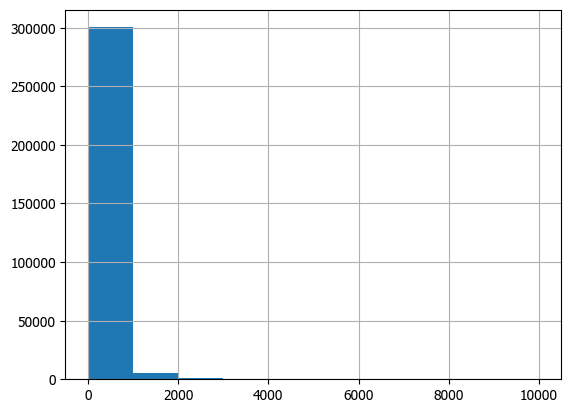

In [24]:
df['text_length'].hist()

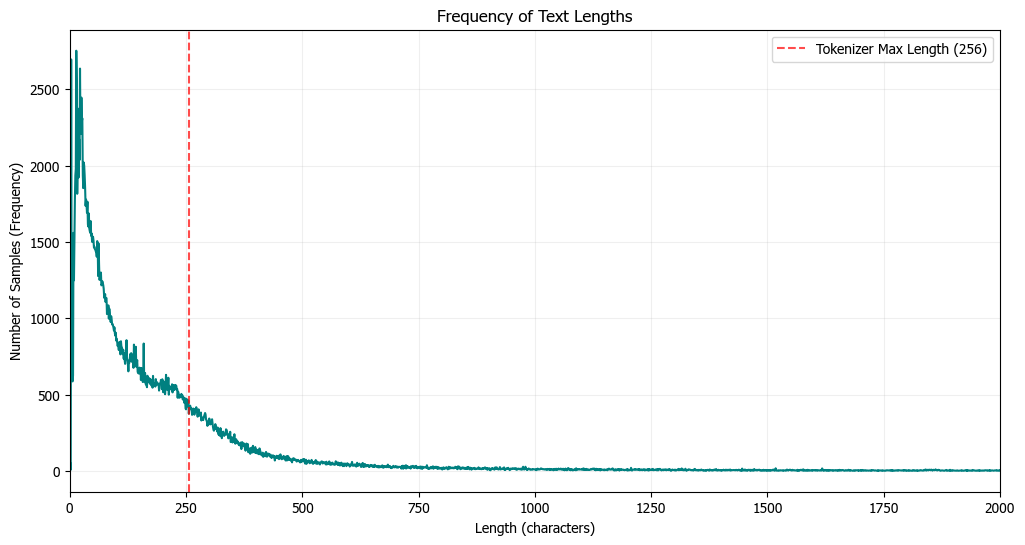

In [69]:
# 1. นับว่าแต่ละความยาว (ตัวอักษร) มีจำนวนกี่แถว
length_counts = df['text_length'].value_counts().sort_index()

plt.figure(figsize=(12, 6))

# 2. พล็อตแกน X = ความยาวประโยค, แกน Y = จำนวนประโยคที่มีความยาวนั้น
plt.plot(length_counts.index, length_counts.values, color='teal', linewidth=1.5)

# 3. ใส่จุดสังเกต (Optional) เช่น max_length ที่คุณใช้ (256)
plt.axvline(x=256, color='red', linestyle='--', alpha=0.7, label='Tokenizer Max Length (256)')

plt.title('Frequency of Text Lengths')
plt.xlabel('Length (characters)')
plt.ylabel('Number of Samples (Frequency)')
plt.legend()
plt.grid(True, alpha=0.2)

# จำกัดขอบเขตแกน X เพื่อให้เห็นภาพรวมชัดขึ้น (เช่น 0-2000 ตัวอักษร)
plt.xlim(0, 2000) 

plt.show()

In [25]:
p95 = df['text_length'].quantile(0.95)
p95

584.0

In [26]:
min_val = df['text_length'].min()
shortest_df = df[df['text_length'] == min_val]
shortest_df
# ข้อมูลพวกนี้อจต้อง clean ออก

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200,text_length
1709,1709,ฟ,0,0,0,0,0,0,0,0,0,0,0,0,1
11814,11814,1,0,0,0,0,0,0,0,0,0,0,0,0,1
13688,13688,K,0,0,0,0,0,0,0,0,0,0,0,0,1
17656,17656,?,0,0,0,0,0,0,0,0,0,0,0,0,1
22152,22152,1,0,0,0,0,0,0,0,0,0,0,0,0,1
24204,24204,1,1,0,0,0,0,0,0,0,0,0,0,0,1
25930,25930,1,0,0,0,0,0,0,0,0,0,0,0,0,1
37868,37868,1,0,0,0,0,0,0,0,0,0,0,0,0,1
42749,42749,1,0,0,0,0,0,0,0,0,0,0,0,0,1
44943,44943,1,0,0,0,0,0,0,0,0,0,0,0,0,1


In [27]:
pd.set_option('display.max_colwidth', None)
max_val = df['text_length'].max()
longest_df = df[df['text_length'] == max_val]
longest_df['comment']

287235    เรียนท่านผู้ว่าราชการกรุงเทพมหานคร อธิบดีกรมเจ้าท่า และผู้อำนวยการเขตสัมพันธวงศ์\nเลขรับแจ้ง 2024-H33YVA เมื่อวันที่ 30 สิงหาคม 2567 เนื่องด้วยเหตุการณ์ส่วนต่อขยายร้านอาหารถล่ม ทรุดตัวของร้านอาหารเมื่อวานวันที่ 28 พฤษภาคม 2567 มีเสียงดังเกิดขึ้นประมาณ 10.00-11.00 น. ในซอยเจ้าสัวสอน ตรอกตลาดน้อย เขตสัมพันธวงศ์ ตามภาพ ที่เคยได้ยื่นเรื่องผ่านระบบ Traffy Fondue เลขที่ 2024-4367K8 และทางเขตสัมพันธวงศ์ ได้มีหนังสือเลขที่  กท4203/1946 ลงวันที่ 29 พฤษภาคม 2567 ให้ทางร้านอาหารดังกล่าว ดำเนินการให้เสร็จภายใน 30 วัน และหนังสือเลขที่ กท4203/2229 ลงวันที่ 21 มิถุนายน 2567  เรื่องร้านอาหารบ้านริมน้ำทรุดตัว อาคารโครงสร้างไม้ชั้นเดียว ขนาดประมาณ 7.00 x 20.00 เมตร ซึ่งก่อสร้างยื่นล้ำลงในแม่น้ำเจ้าพระยา (อยู่นอกเขื่อน) ทรุดตัวลงในแม่น้ำเจ้าพระยาฯ ตามภาพถ่าย สำนักงานเขตสัมพันธวงศ์ขอความร่วมมือกรมเจ้าท่าตรวจสอบร้านอาหารบ้านริมน้ำมีใบอนุญาตก่อสร้างรุกล้ำลำน้ำกับกรมเจ้าท่าหรือไม่? กรมเจ้าท่าลงรับ 21 มิถุนายน 2567 เวลา 10.07 นั้น\n1. ตามที่ทางฝ่ายโยได้ตอบกลับผ่าน Traffy Fondue ความว่าการซ่อมแซมอาคา

In [28]:
pd.reset_option('display.max_colwidth')

In [29]:
longest_df

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200,text_length
287235,287235,เรียนท่านผู้ว่าราชการกรุงเทพมหานคร อธิบดีกรมเจ...,0,0,0,0,0,0,0,0,0,0,0,0,9999


- sampling เพื่อหาคำที่ปรากฎบ่อยในแต่ละ class
- คำที่ใช้บ่อย/ปรากฏทุก class -> เลยไม่มีความสำคัญ (ต้อง handle ต่อ)

In [30]:
# load tokenizer from phayathaibert
checkpoint = "clicknext/phayathaibert"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_and_clean(text) : 
    tokens = tokenizer.tokenize(str(text)) # แบ้งเปนคำๆ
    cleaned_tokens = [] # clean ข้อมูล
    for t in tokens : 
        t = t.replace('<s>', '').replace('</s>', '') # ลบ spacial seq : <s> beginning of seq, </s> end of seq ที่ model สร้างขึ้น
        t.replace(' ', '') # ลบ space ที่ถูกตัดออกมาเปนคำออก
        t = re.sub(r'[^ก-๙a-zA-Z0-9]', '', t) # ลบเครื่องหมายทุกอย่าง
        if len(t) > 1:
            cleaned_tokens.append(t) # เอาเฉพาะคำที่ยาวมากกว่า 1
    return cleaned_tokens

In [31]:
# sampling ข้อมูลของแต่ละ class
docs = []
class_names = []

for col in target_columns:
    subset = df[df[col] == 1]['comment']
    if len(subset) > 0:
        sample_size = min(1000, len(subset)) # สุ่มมาแค่ 1000 แต่บางหน่วยงานมีไม่ถึง 1000
        subset = subset.sample(sample_size, random_state=42)
        all_text = " ".join(subset.astype(str).tolist()) # มัดรวมข้อความทั้งหมดของ 1 หน่วยงานให้เปนก้อนเดียว เพื่อให้ง่ายต่อการหาคำปรากฎบ่อย
        docs.append(all_text)
        class_names.append(col)

In [32]:
# tfidf
tfidf = TfidfVectorizer(
    ngram_range=(1,3), # tri-gram
    tokenizer=tokenize_and_clean,
    max_df=0.9, # คำไหนปรากฎเกือบทุก class -> ไม่มีประโยชน์
    min_df=2, # ป้องกันคำพิมผิด เช่น มแว
    use_idf=True, # default
    smooth_idf=True, # default
    sublinear_tf=True # log scale เพื่อกดคำที่มีความถี่สูงมาก เพื่อมีคนพิมมาซ้ำๆ
)

train_tfidf = tfidf.fit_transform(docs)
feature_names = tfidf.get_feature_names_out() # เอารายการคำทั้งหมดออกมา

Token indices sequence length is longer than the specified maximum sequence length for this model (45509 > 510). Running this sequence through the model will result in indexing errors


In [33]:
dense_matrix = train_tfidf.todense() # ตอนแรก train_tfidf เกบเปน sparse matrix เพื่อประหยัดที่โดยการไม่เกบ 0, แต่เราแปลงเปน dense ด้วยการเติม 0 ให้ช่องที่หายไป เพื่อที่จะได้อ่านค่าง่ายขึ้น

for i, class_name in enumerate(class_names):
    scores = dense_matrix[i].tolist()[0]
    word_scores = [(feature_names[j], scores[j]) for j in range(len(scores)) if scores[j] > 0]
    word_scores = sorted(word_scores, key=lambda x: x[1], reverse=True)
    
    top_10 = [word for word, score in word_scores[:10]]
    print(f"{class_name}:")
    print(f"   -> {', '.join(top_10)}")

สำนักงานตำรวจแห่งชาติ:
   -> ห้าม จอด, ย้อน, ย้อน ศร, จอด กีดขวาง, ที่ ห้าม, บก, มีรถ จอด กีดขวาง, รถ มาจอด, พบ รถ, ใน ที่
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย:
   -> รถไฟฟ้าสาย สีม่วง, รฟม, ก่อสร้าง รถไฟฟ้า, สีม่วง, เส้น จราจร, pk, โครงการ รถไฟฟ้าสาย, เส้นทาง ม้าลาย, ไม่มี เส้น, สถานี
สภาเด็กและเยาวชนกรุงเทพมหานคร:
   -> อาจ ได้รับ, อาจ ได้รับ อันตราย, เด็ก มา, และเยาวชน, ขอทาน, อบรม, ตั้ง เวที, เด็ก และเยาวชน, 13 14, 13 14 เม
กรมควบคุมมลพิษ:
   -> เผา, การเผา, ควัน, กลิ่น ควัน, เปิดเพลง เสียงดัง, กลิ่น, และ ควัน, pm 25, ได้กลิ่น, เหม็น
กรมสรรพสามิต:
   -> น่า สุรา, สุรา, ขาย สุรา, โดยไม่มี ใบอนุญาต, เหล้า, ใบอนุญาต น่า, เปิด ขาย, ใบอนุญาต, ร้าน, ร้าน ดังกล่าว
การไฟฟ้านครหลวง:
   -> วน ดวง, รุด วน ดวง, ส่องสว่าง ทาง, ดับ รุด, ทาง ดับ, ส่องสว่าง ทาง ดับ, ไฟฟ้า ส่องสว่าง ทาง, พบ ดวง, ทาง ดับ รุด, ดวง ไฟฟ้า
กรมทางหลวง:
   -> มี ร้านค้า, ขายของ บน ทาง, กัล, กัล พฤกษ์, ถนน าญจนาภิเษก, กรมทางหลวง, ขายของ บน, ทาง ดับ, ดับ รุด, ส่องสว่าง ทาง
สำนักงานประกันสุขภาพแห่งชาติ:
   -> ปฐม, นัด, สาธารณสุ

In [34]:
# คำที่ต้อง clean เพิ่ม
# _ | อาจ ได้รับ | ผม มีเรื่อง | ลงชื่อ | ควัน vs และ ควัน (และ) | น่า สุรา vs สุรา (น่า) ...
# กระทรวงการท่องเที่ยวและกีฬา มักเจอคำภาษาอังกฤษ และ #?

In [ ]:
# นับว่าคำต่างๆ ทั้งที่ควรกำจัด หรือคำอื่นๆที่น่าสนใจ ปรากฏทั้งหมดกี่ครั้ง
unwanted_words = ['ครับ', 'ค่ะ', 'นะคะ', 'นะครับ', 'นะคับ', 'คับ', 'นะค่ะ', 'ผม', 'มีเรื่อง', 'ลงชื่อ','นะ', 'สิ', 'หน่อย', 'อะ', 'อ่ะ', 'จ้า', 'จ๊ะ', 'ด้วย', 'จ่ะ', 'ละ', 'เด้อ', 'ขอบคุณ', 'ขอบคุณครับ', 'ขอบคุณค่ะ','แจ้ง', 'ร้องเรียน', 'สอบถาม', 'ช่วย', 'รบกวน', 'ขออนุญาต', 'ประสานงาน', 'แก้ไข', 'ติดตาม', 'ดำเนินการ', 'ตรวจสอบ', 'อยากให้', 'กรุณา', 'รบกวนหน่อย','ตอนนี้', 'วันนี้', 'เมื่อวาน', 'พรุ่งนี้', 'ขณะนี้', 'ที่นี่', 'ตรงนี้', 'แถว', 'ช่วง', 'บริเวณ','ดิฉัน', 'หนู', 'เรา', 'ท่าน', 'แก', 'มัน', 'เจ้าหน้าที่']

def count_unwanted_words(df, word_list):
    total_rows = len(df)
    for word in word_list:
        count = df['comment'].str.contains(word, na=False).sum()
        percentage = (count / total_rows) * 100
        print(f"found '{word}': {count} time ({percentage:.2f}%)")

count_unwanted_words(df, unwanted_words)

พบคำว่า 'ครับ': 43807 ครั้ง (14.30%)
พบคำว่า 'ค่ะ': 26497 ครั้ง (8.65%)
พบคำว่า 'นะคะ': 4184 ครั้ง (1.37%)
พบคำว่า 'นะครับ': 3705 ครั้ง (1.21%)
พบคำว่า 'นะคับ': 106 ครั้ง (0.03%)
พบคำว่า 'คับ': 3883 ครั้ง (1.27%)
พบคำว่า 'นะค่ะ': 331 ครั้ง (0.11%)
พบคำว่า 'ผม': 5119 ครั้ง (1.67%)
พบคำว่า 'มีเรื่อง': 308 ครั้ง (0.10%)
พบคำว่า 'ลงชื่อ': 63 ครั้ง (0.02%)
พบคำว่า 'นะ': 15357 ครั้ง (5.01%)
พบคำว่า 'สิ': 24888 ครั้ง (8.12%)
พบคำว่า 'หน่อย': 10980 ครั้ง (3.58%)
พบคำว่า 'อะ': 20784 ครั้ง (6.78%)
พบคำว่า 'อ่ะ': 209 ครั้ง (0.07%)
พบคำว่า 'จ้า': 46830 ครั้ง (15.28%)
พบคำว่า 'จ๊ะ': 42 ครั้ง (0.01%)
พบคำว่า 'ด้วย': 39761 ครั้ง (12.98%)
พบคำว่า 'จ่ะ': 14 ครั้ง (0.00%)
พบคำว่า 'ละ': 91941 ครั้ง (30.00%)
พบคำว่า 'เด้อ': 25 ครั้ง (0.01%)
พบคำว่า 'ขอบคุณ': 9944 ครั้ง (3.25%)
พบคำว่า 'ขอบคุณครับ': 2478 ครั้ง (0.81%)
พบคำว่า 'ขอบคุณค่ะ': 1416 ครั้ง (0.46%)
พบคำว่า 'แจ้ง': 46478 ครั้ง (15.17%)
พบคำว่า 'ร้องเรียน': 10838 ครั้ง (3.54%)
พบคำว่า 'สอบถาม': 3327 ครั้ง (1.09%)
พบคำว่า 'ช่วย': 28035 ครั้ง (9.15%)


In [ ]:
# คำที่จะเอาไปทำ feature eng
# 'ครับ', 'ค่ะ', 'นะคะ', 'นะครับ', 'นะคับ', 'คับ', 'นะค่ะ', 'ผม', 'มีเรื่อง','ลงชื่อ','นะ','หน่อย','อะ','อ่ะ','จ้า', 'จ๊ะ', 'จ่ะ', 'เด้อ','ด้วย','ขอบคุณครับ', 'ขอบคุณค่ะ', 'ขอบคุณ'

In [55]:
focus_word = ['จอดรถกีดขวาง', 'ย้อนศร', 'จอดรถในที่ห้ามจอด', 'รถไฟฟ้า', 'รฟม', 'pm2.5', 'ไฟดับ','เสาไฟฟ้าเอียง','น้ำไม่ไหล','ขอทาน', 'ขายเหล้า', 'ขายสุราโดยไม่มีใบอนุญาติ']
count_unwanted_words(df, focus_word)

พบคำว่า 'จอดรถกีดขวาง': 1611 ครั้ง (0.53%)
พบคำว่า 'ย้อนศร': 1134 ครั้ง (0.37%)
พบคำว่า 'จอดรถในที่ห้ามจอด': 331 ครั้ง (0.11%)
พบคำว่า 'รถไฟฟ้า': 3126 ครั้ง (1.02%)
พบคำว่า 'รฟม': 118 ครั้ง (0.04%)
พบคำว่า 'pm2.5': 174 ครั้ง (0.06%)
พบคำว่า 'ไฟดับ': 2194 ครั้ง (0.72%)
พบคำว่า 'เสาไฟฟ้าเอียง': 115 ครั้ง (0.04%)
พบคำว่า 'น้ำไม่ไหล': 244 ครั้ง (0.08%)
พบคำว่า 'ขอทาน': 1368 ครั้ง (0.45%)
พบคำว่า 'ขายเหล้า': 97 ครั้ง (0.03%)
พบคำว่า 'ขายสุราโดยไม่มีใบอนุญาติ': 0 ครั้ง (0.00%)
